# Multi-Subreddit EDA

Following the single-subreddit analysis, where titles alone showed little signal for engagement, this notebook expands the dataset to introduce variation in topic, tone, and safety. The aim is to understand how subreddits differ and select a subset that gives the model something more meaningful to learn from.

🎯 **Goal**: Select a balanced set of subreddits that introduces variation in safety and engagement without introducing extreme differences in scale.

**Approach**:

1. Compare all available subreddits using summary metrics (engagement and NSFW rate)  
2. Inspect safety and engagement of subreddits
3. Select a shortlist that spans both dimensions while avoiding outliers  

### ⭐️ Executive Summary

The dataset is clean and consistent across subreddits, with ~1,000 posts per topic. Engagement is highly skewed and required careful definition; a scaled combination of score and comment count was used to ensure both signals contributed.

Most subreddits are effectively safe, with a small number introducing meaningful variation in Not Safe For Work (NSFW) content. Engagement varies more widely, with some clear outliers.

A shortlist of subreddits was selected to span both safety and engagement while avoiding extremes. Initial modelling on a single subreddit showed little signal in titles alone, so this expanded dataset is designed to introduce enough variation to test whether meaningful patterns can be learned.

### Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## 1. Light EDA: All Subreddits

In [2]:
# Load list of subreddits
subreddits_list = pd.read_csv("../data/50_subreddits_list.csv")
subreddits_list.head()

,subreddits
0,funny
1,AskReddit
2,gaming
3,aww
4,Music


In [3]:
# Create list of subreddit topics
subreddits = subreddits_list["subreddits"].tolist()

# Dictionary of subreddit dataframes
subreddit_dfs = {}

# List to collect analysis summary rows per subreddit
eda_rows = []

# Dictionary to collect sample titles
sample_titles = {}

# Loop through subreddits to understand data
for topic in subreddits:

    # Create subreddit dataframe
    data_path = f"../data/{topic}.csv"
    df = pd.read_csv(data_path)

    # Add to dict
    subreddit_dfs[topic] = df

    # Analyse: Mini EDA
    count = len(df)
    shape = df.shape
    mean_score = df["score"].mean()
    median_score = df["score"].median()
    nsfw_rate = df["is_nsfw"].mean()
    mean_title_length = df["title"].str.len().mean()
    score_q75 = df["score"].quantile(0.75)
    comments_q75 = df["num_comments"].quantile(0.75)

   # Sample titles
    sample_titles[topic] = df["title"].sample(5, random_state=42).to_list()

    # Add to analysis summary
    eda_rows.append({
        "topic": topic,
        "rows": count,
        "columns": shape[1],
        "mean_score": mean_score,
        "median_score": median_score,
        "nsfw_rate": nsfw_rate,
        "mean_title_length": mean_title_length,
        "score_q75": score_q75,
        "comments_q75": comments_q75
    })

# Create analysis dataframe and sort
subreddit_eda = pd.DataFrame(eda_rows)
subreddit_eda = subreddit_eda.sort_values("rows", ascending=False).reset_index(drop=True)

# Print analysis dataframe (without samples)
subreddit_eda


,topic,rows,columns,mean_score,median_score,nsfw_rate,mean_title_length,score_q75,comments_q75
0,WritingPrompts,1000,19,12920.841000,11455.5,0.001000,229.569000,13824.25,343.25
1,videos,998,19,56106.892786,49578.0,0.027054,85.759519,61374.00,3624.00
2,askscience,998,19,9952.669339,8536.0,0.003006,110.775551,10989.75,863.00
3,television,998,19,31721.151303,27246.0,0.004008,84.595190,34952.00,2639.25
4,news,997,19,87968.075226,80638.0,0.001003,77.988967,93784.00,6981.00
5,creepy,997,19,18462.038114,15072.0,0.057172,32.803410,20593.00,689.00
6,IAmA,997,19,24388.118355,18260.0,0.032096,121.509529,27231.00,3813.00
7,travel,997,19,8563.135406,7127.0,0.002006,79.258776,9092.00,233.00
8,Anime,996,19,14327.318273,13229.5,0.033133,53.048193,15838.25,690.25
9,technology,996,19,53088.688755,48052.0,0.001004,96.617470,59290.75,3662.25


### Length

In [4]:
# Inspect length of each subreddit
subreddit_eda["rows"].describe()

count      50.000000
mean      985.320000
std        21.472754
min       871.000000
25%       986.250000
50%       992.500000
75%       996.000000
max      1000.000000
Name: rows, dtype: float64

### Suitability

ℹ️ NSFW = Not Safe For Work (a good proxy for safety)

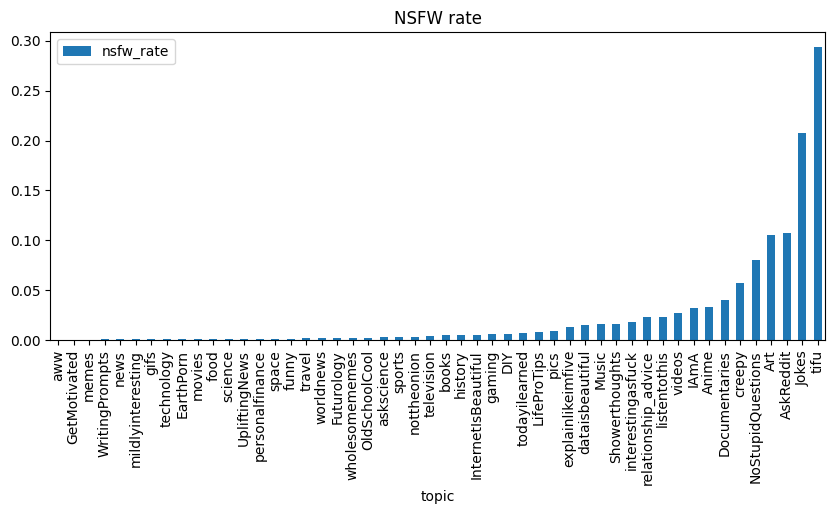

In [12]:
subreddit_eda.sort_values("nsfw_rate").plot(
    x="topic",
    y="nsfw_rate",
    kind="bar",
    figsize=(10,4),
    title="NSFW rate"
);

In [ ]:
# Bucket NSFW rates into low, medium and high ratios
def nsfw_bucket(x):
    if x < 0.02:
        return "low"
    elif x < 0.10:
        return "medium"
    else:
        return "high"

subreddit_eda["nsfw_bucket"] = subreddit_eda["nsfw_rate"].apply(nsfw_bucket)

In [17]:
subreddit_eda["nsfw_bucket"].value_counts()

nsfw_bucket
low       38
medium     8
high       4
Name: count, dtype: int64

In [7]:
subreddit_eda[["topic", "nsfw_rate", "nsfw_bucket"]].sort_values("nsfw_rate")

,topic,nsfw_rate,nsfw_bucket
24,aww,0.000000,low
47,GetMotivated,0.000000,low
40,memes,0.000000,low
0,WritingPrompts,0.001000,low
4,news,0.001003,low
16,mildlyinteresting,0.001004,low
12,gifs,0.001004,low
9,technology,0.001004,low
11,EarthPorn,0.001004,low
17,movies,0.001005,low


### Performance (Engagement)

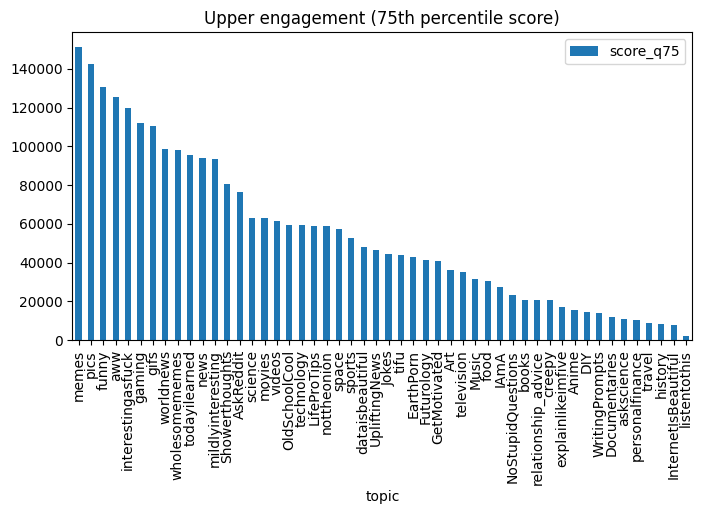

In [11]:
subreddit_eda.sort_values("score_q75", ascending=False).plot(
    x="topic",
    y="score_q75",
    kind="bar",
    figsize=(8,4),
    title="Upper engagement (75th percentile score)"
);

In [20]:
# Bucket engagement scores
subreddit_eda["engagement_bucket"] = pd.qcut(
    subreddit_eda["score_q75"],
    q=3,
    labels=["low", "medium", "high"]
)

subreddit_eda["engagement_bucket"].value_counts()

engagement_bucket
low       17
high      17
medium    16
Name: count, dtype: int64

In [21]:
subreddit_eda[["topic","score_q75","engagement_bucket"]].sort_values("score_q75")

,topic,score_q75,engagement_bucket
42,listentothis,2327.00,low
48,InternetIsBeautiful,7846.50,low
25,history,8427.75,low
7,travel,9092.00,low
27,personalfinance,10514.50,low
2,askscience,10989.75,low
18,Documentaries,12232.00,low
0,WritingPrompts,13824.25,low
34,DIY,14591.00,low
8,Anime,15838.25,low


### 💡 Multi-subreddit EDA Summary

Across the candidate subreddits, dataset size is consistent (~1,000 posts each), so differences in results are driven by content rather than scale.

**NSFW rates are heavily skewed towards zero**, with most subreddits effectively safe. A small number introduce moderate (≈2–10%) and higher (>10%) levels of NSFW content, providing enough variation to support suitability analysis.

**Engagement varies more widely**. Using the 75th percentile score as a proxy highlights clear differences between subreddits, with some consistently higher-performing than others. To make this easier to reason about, subreddits were grouped into low, medium, and high engagement buckets based on relative ranking.

These buckets are used as a simple way to compare subreddits and avoid mixing extreme outliers when selecting a modelling dataset.

## 2. Safety and Engagement Trade-offs

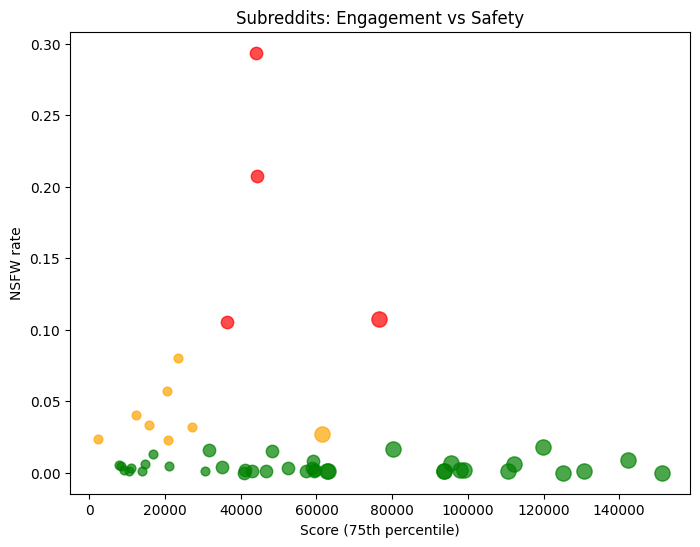

In [29]:
# Use colours to indicate NSFW ratios
colors = {
    "low": "green",
    "medium": "orange",
    "high": "red"
}

# Use dot size to indicate engagement score
size_map = {
    "low": 40,
    "medium": 80,
    "high": 120
}

plt.figure(figsize=(8,6))

for _, row in subreddit_eda.iterrows():
    plt.scatter(
        row["score_q75"],
        row["nsfw_rate"],
        color=colors[row["nsfw_bucket"]],
        s=size_map[row["engagement_bucket"]],
        alpha=0.7
    )

plt.xlabel("Score (75th percentile)")
plt.ylabel("NSFW rate")
plt.title("Subreddits: Engagement vs Safety")

plt.show()

#### 💡 Selecting subreddits
A scatter plot of engagement (75th percentile score) versus NSFW rate was used to compare candidate subreddits across performance and safety:
- Most subreddits cluster at very low NSFW rates, with a small number providing meaningful variation. 
- Engagement levels vary more widely, with a few clear outliers at both the low and high ends.

**A shortlist of subreddits were selected to span low, medium, and high NSFW levels while avoiding extreme engagement outliers**. 

In practice, this meant focusing on a mid-range band of engagement where most subreddits sit, and choosing a mix of topics within that range. This keeps the engagement label broadly comparable across subreddits, while introducing enough variation in tone and safety to support later modelling of category and suitability.

Note: This subset (~7k posts across selected subreddits) will be used to validate the approach before scaling further. The goal at this stage is to test whether additional variation in topic and safety improves the signal, rather than to optimise model performance with a larger dataset.

In [31]:
shortlist = ["aww","todayilearned","gaming","NoStupidQuestions","creepy","AskReddit","tifu"]

subreddit_eda[subreddit_eda["topic"].isin(shortlist)] \
    .sort_values("nsfw_rate")[["topic","nsfw_rate","score_q75"]]

,topic,nsfw_rate,score_q75
24,aww,0.000000,125237.00
15,gaming,0.006024,112261.75
39,todayilearned,0.007121,95527.00
5,creepy,0.057172,20593.00
37,NoStupidQuestions,0.080122,23543.00
35,AskReddit,0.107396,76646.00
20,tifu,0.293763,44033.50


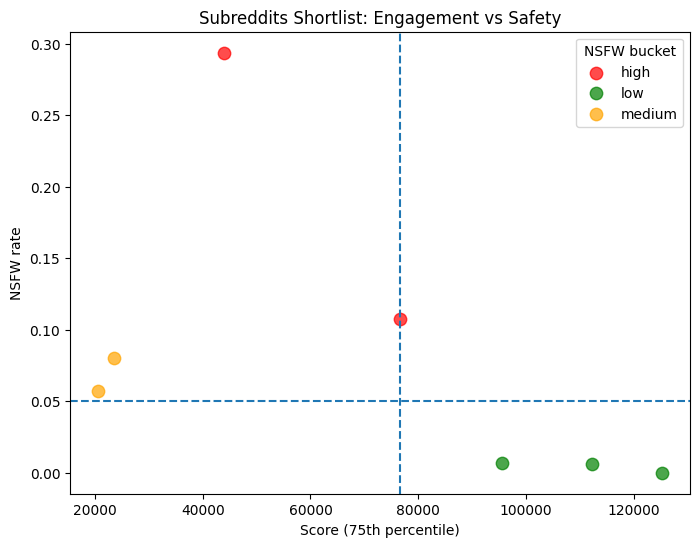

In [35]:
shortlist_df = subreddit_eda[subreddit_eda["topic"].isin(shortlist)]

plt.figure(figsize=(8,6))

colors = {
    "low": "green",
    "medium": "orange",
    "high": "red"
}

# Scatter
for bucket, group in shortlist_df.groupby("nsfw_bucket"):
    plt.scatter(
        group["score_q75"],
        group["nsfw_rate"],
        color=colors[bucket],
        label=bucket,
        s=80,
        alpha=0.7
    )

# Add horizontal line (NSFW threshold ~0.05)
plt.axhline(0.05, linestyle="--")

# Add vertical line (median engagement)
median_score = shortlist_df["score_q75"].median()
plt.axvline(median_score, linestyle="--")

plt.xlabel("Score (75th percentile)")
plt.ylabel("NSFW rate")
plt.title("Subreddits Shortlist: Engagement vs Safety")

plt.legend(title="NSFW bucket")
plt.show()

#### 💡 Distribution of Shortlist Subreddits

Plotting engagement against NSFW rate made it much easier to see how the candidate subreddits differ. Most sit very close to zero on NSFW, with a small number introducing meaningful variation, while engagement varies more widely across the set.

The shortlist focuses on subreddits that sit in a similar engagement range but spread across low, medium, and high NSFW levels. This avoids mixing extremes while still introducing enough variation in tone and safety to make the next stage of modelling worthwhile.

## 3. Inspect Shortlist

In [36]:
# Return edited version of EDA for shortlist
subreddit_eda[subreddit_eda["topic"].isin(shortlist)]

,topic,rows,columns,mean_score,median_score,nsfw_rate,mean_title_length,score_q75,comments_q75,nsfw_bucket,engagement_bucket
5,creepy,997,19,18462.038114,15072.0,0.057172,32.803410,20593.00,689.00,medium,low
15,gaming,996,19,104897.175703,98456.5,0.006024,52.787149,112261.75,2691.50,low,high
20,tifu,994,19,39764.600604,35220.0,0.293763,61.091549,44033.50,2167.75,high,medium
24,aww,993,19,118494.673716,111549.0,0.000000,64.065458,125237.00,1587.00,low,high
35,AskReddit,987,19,72183.582573,66186.0,0.107396,94.696049,76646.00,23715.00,high,high
37,NoStupidQuestions,986,19,21049.848884,18224.5,0.080122,105.994929,23543.00,3006.00,medium,low
39,todayilearned,983,19,88837.550356,83475.0,0.007121,231.145473,95527.00,3059.00,low,high


In [38]:
# Print samples for subreddits shortlist
for topic in shortlist:
    print (f"\nSample titles for reddit/{topic}:")
    for title in sample_titles[topic]:
        print(f" - {title}")


Sample titles for reddit/aww:
 - My dad who didn’t want a dog right after my family got a new puppy
 - When you partied too hard last night, now you gotta clean up the litter the next morning
 - This pair went viral a couple months ago because they were a blind dog and his guide dog, here's just an update to say they're doing wonderful
 - Wonders why the air is so spicy?
 - Sometimes he gives me his baby when I come home from work

Sample titles for reddit/todayilearned:
 - TIL A Group Of Flat Earthers Spend $20,000 Trying To Prove Earth Is Flat, Accidentally Prove It's Round
 - TIL that veterinarians kill themselves at rates 2.5 to 3.5 times the general population, due in part to online trolling and threats from pet owners who blame them for the death of a pet, and easy access to lethal medicines
 - TIL that André the Giant grew so fast that his own parents didn't recognize him. He left home at 14 and returned at 19, having already become a professional wrestler. As he explained his 

#### 🙋‍♀️ Shortlist Samples

Sample titles show clear differences in tone and structure across subreddits, ranging from short, meme-like posts to longer, narrative or question-based formats. This suggests there is enough variation in language for the model to potentially learn meaningful patterns.

Some subreddits include very short titles (e.g. “Oh no”, “underneath”), which may limit the amount of signal available from text alone. This reinforces the earlier observation that title-based models are likely to be noisy, but still worth testing given the broader variation across the dataset.

## Conclusion & Next Steps

Moving from a single subreddit to a multi-subreddit view introduces meaningful variation in both safety and engagement, which was not possible in the initial analysis.

Safety is largely uniform with a small number of outliers, while engagement varies more continuously across subreddits. This makes selection important: combining subreddits naively would introduce large differences in scale, making the performance label harder to interpret.

The final shortlist balances these dimensions by keeping engagement within a similar range while deliberately including variation in NSFW levels. This creates a dataset that is better suited to testing whether engagement and suitability signals can be learned from text.

**Next steps:**

- Combine the selected subreddits into a single dataset  
- Recreate the engagement label on the combined data  
- Train a baseline model to test whether additional variation improves signal  
- Decide whether to scale the dataset further or revisit feature and label design  